# Phase 2 · 6단원 — K-최근접 이웃과 거리

> **다 외워 두고, 예측할 땐 이웃에게 물어봅니다. 가장 단순한데 진짜로 잘 되는 알고리즘입니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/06-knn-and-distances>
- 예상 시간: 90분 · 선수 지식: Phase 1 14단원(노름과 거리)

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **KNN 분류기와 회귀기**를 밑바닥부터 만듭니다 (K 조절, 거리 가중 투표 포함).
2. **L1·L2·코사인·민코프스키** 거리를 비교하고, 데이터에 맞는 걸 고릅니다.
3. **차원의 저주**를 설명하고, 차원이 높아지면 KNN이 왜 망가지는지 직접 보입니다.
4. **KD-트리**를 만들어 빠르게 이웃을 찾고, 언제 무차별 탐색보다 나은지 따져 봅니다.

### 🔑 지금까지와 완전히 다른 점

| | 2~5단원 | 6단원 (KNN) |
| --- | --- | --- |
| 학습 | 파라미터를 찾음 (w, b, 트리 구조…) | **아무것도 안 함. 그냥 저장** |
| 예측 | 저장한 파라미터로 계산 | **그때그때 전부 뒤져서 이웃 찾기** |
| 훈련 시간 | 오래 걸림 | **0초** |
| 예측 시간 | 빠름 | **느림** |

> **KNN은 "공부는 안 하고 시험장에 교과서를 통째로 들고 들어가는" 학생입니다.**

### 🏭 이게 왜 지금 중요한가요?

> 📗 **원문** — "KNN also shows up everywhere in modern AI, just under different names."

KNN은 옛날 알고리즘이 아닙니다. **이름만 바뀌어서 최신 AI 곳곳에 있습니다.**

- **벡터 데이터베이스** — 임베딩끼리 KNN 검색
- **RAG (검색 증강 생성)** — 질문과 가장 가까운 문서 조각 K개 찾기
- **추천 시스템** — 나와 비슷한 사용자 K명 찾기

**알고리즘은 똑같습니다.** 규모와 자료구조만 다를 뿐이에요.

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 이웃에게 물어보기 — KNN이 하는 일 | 📗 원문 |
| 1 | 🔨 거리 함수 네 가지 | 📗 원문 + ✨ 손 계산 |
| 2 | 🔨 KNN 만들기 | 📗 원문 |
| 3 | 🔑 K를 몇으로 할까 | 📗 원문 + ✨ 실험 |
| 4 | 어떤 거리를 써야 하나 | 📗 원문 + ✨ 텍스트 실험 |
| 5 | 가중 KNN — 가까운 이웃에게 더 큰 표를 | 📗 원문 + ✨ 실험 |
| 6 | 스케일링은 선택이 아닙니다 | 📗 원문 + ✨ 실험 |
| 7 | 🔑 차원의 저주 | 📗 원문 + ✨ 직접 재기 |
| 8 | 🔨 KD-트리로 빠르게 찾기 | 📗 원문 + ✨ 속도 측정 |
| 9 | 게으른 학습 vs 부지런한 학습 | 📗 원문 + ✨ 시간 측정 |
| 10 | KNN 회귀 — 외삽을 못 합니다 | 📗 원문 + ✨ 실험 |
| 11 | 실무 — sklearn과 벡터 검색 | 📗 원문 |
| 12 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 "이웃 K명에게 물어본다"는 규칙을 세웁니다.
그런데 이 한 문장 안에 **정해지지 않은 게 두 개** 있습니다. **"가깝다"가 뭐지?** 그리고 **"K는 몇이지?"**

- 그래서 **1절**에서 먼저 **거리 함수**를 정합니다. "가깝다"를 정의해야 이웃을 뽑을 수 있으니까요.
- 거리가 생겼으니 **2절**에서 드디어 **KNN을 만들 수 있습니다.**
- 만들고 보니 남은 손잡이가 **K** 하나입니다 → **3절**에서 K를 고릅니다.
- K를 골랐더니, 1절에서 대충 정한 **거리 선택이 결과를 바꾼다**는 걸 알게 됩니다 → **4절**.
- 여기서 또 의문이 생깁니다. **이웃 K명에게 표를 똑같이 주는 게 맞나?** → **5절 가중 KNN**.

여기까지가 "KNN을 제대로 쓰는 법"입니다. 이제 **KNN이 깨지는 지점** 세 개를 봅니다.

- **6절** — 거리가 **특징 단위**에 휘둘립니다. (단위만 바꿔도 성능이 무너집니다)
- **7절** — 단위를 맞춰도 **차원이 높으면** 거리 자체가 의미를 잃습니다. **차원의 저주**입니다.
- **8절** — 그리고 **느립니다.** KD-트리로 빠르게 만들어 봅니다. …그런데 **7절의 저주 때문에 트리도 고차원에선 소용없습니다.** 두 절이 여기서 만납니다.
- **9절** — 왜 느린 게 당연한지, 구조적인 이유를 정리합니다 (**게으른 학습**).

마지막으로 **10절**에서 분류 대신 **회귀**로 넓히고, 여기서 KNN의 마지막 한계(**외삽 불가**)가 드러납니다.
**11절**은 이 전부가 오늘날 **RAG·벡터 DB**에서 어떻게 쓰이는지입니다.

### 한 줄로 꿰면

> **이웃에게 묻자(0) → 그럼 "가깝다"를 정하고(1) → 만들고(2) → K 고르고(3) → 거리 고르고(4) → 표 무게 주고(5)
> → 단위 맞추고(6) → 차원 줄이고(7) → 빨리 찾고(8) → 왜 느린지 알고(9) → 회귀로 넓히고(10) → 실무로(11)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
import time
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 이웃에게 물어보기 — KNN이 하는 일

> 📗 **원문** — "How KNN works"

새 점 하나가 들어왔습니다. 이게 무슨 종류인지 맞혀야 합니다. KNN의 답은 이렇습니다.

> **"가장 가까운 이웃 K명에게 물어보고, 많이 나온 답을 따른다."**

### 📗 알고리즘 전체 (정말 이게 다입니다)

1. 새 점에서 **모든 훈련 점까지의 거리**를 잽니다
2. 거리 순으로 **정렬**합니다
3. 가장 가까운 **K개**를 뽑습니다
4. **분류**면 → 다수결 / **회귀**면 → 평균

> 📗 원문: "That is the entire algorithm. No fitting. No gradient descent. No epochs."

### 🧸 비유 — 전학 온 학교에서 급식 메뉴 고르기

전학 첫날 급식실에 갔는데 뭘 먹어야 할지 모르겠습니다. 어떻게 하죠?

**주변 사람 5명이 뭘 먹는지 보고 따라 시킵니다.**

- 5명 중 4명이 돈까스 → 돈까스
- "주변"을 몇 명까지 볼지가 **K**입니다
- "가깝다"를 어떻게 잴지가 **거리 함수**입니다

이 두 개가 KNN의 전부입니다. 나머지는 없어요.

> ✨ **추가** — 손으로 한 번 굴려 봅니다. 코드 없이 눈으로 따라가 보세요.

In [2]:
# ✨ 추가 — KNN을 손으로 한 번 굴려 봅니다
훈련점 = np.array([[1.0, 1.0], [1.5, 2.0], [2.0, 1.0],
                   [5.0, 5.0], [5.5, 4.5], [6.0, 5.5]])
훈련답 = np.array(["🍜라면", "🍜라면", "🍜라면", "🍕피자", "🍕피자", "🍕피자"])
질문점 = np.array([2.5, 2.5])

거리들 = np.sqrt(((훈련점 - 질문점) ** 2).sum(axis=1))
순서 = np.argsort(거리들)

print(f"질문: {질문점} 은 라면일까요 피자일까요?\n")
print(f"{'순위':>4}{'훈련 점':>16}{'정답':>10}{'거리':>10}")
print("-" * 42)
for 등수, i in enumerate(순서, 1):
    print(f"{등수:>4}{str(훈련점[i]):>16}{훈련답[i]:>10}{거리들[i]:>10.3f}")

for K in [1, 3, 5]:
    이웃 = 훈련답[순서[:K]]
    답 = Counter(이웃).most_common(1)[0][0]
    print(f"\nK={K} -> 이웃 {list(이웃)} -> 다수결 결과: {답}")

print("\n=> 이게 KNN의 전부입니다. 학습이라는 단계가 아예 없습니다.")

질문: [2.5 2.5] 은 라면일까요 피자일까요?

  순위            훈련 점        정답        거리
------------------------------------------
   1       [1.5 2. ]       🍜라면     1.118
   2         [2. 1.]       🍜라면     1.581
   3         [1. 1.]       🍜라면     2.121
   4         [5. 5.]       🍕피자     3.536
   5       [5.5 4.5]       🍕피자     3.606
   6       [6.  5.5]       🍕피자     4.610

K=1 -> 이웃 ['🍜라면'] -> 다수결 결과: 🍜라면

K=3 -> 이웃 ['🍜라면', '🍜라면', '🍜라면'] -> 다수결 결과: 🍜라면

K=5 -> 이웃 ['🍜라면', '🍜라면', '🍜라면', '🍕피자', '🍕피자'] -> 다수결 결과: 🍜라면

=> 이게 KNN의 전부입니다. 학습이라는 단계가 아예 없습니다.


---

## 1️⃣ 🔨 거리 함수 네 가지

> 🔗 **앞 절과 이어서** — 0절에서 "가장 가까운 이웃 K명"이라고 했습니다.
> 그런데 **"가깝다"가 뭔지 아직 안 정했습니다.** 그걸 정하지 않으면 이웃을 뽑을 수가 없죠.
> 그래서 KNN을 만들기 전에 **거리부터** 정합니다.

> 📗 **원문** — "Distance metrics" + "Build It: Step 1"

"가깝다"를 정하는 게 거리 함수입니다. **뭘 쓰느냐에 따라 이웃이 달라지고, 답도 달라집니다.**

| 거리 | 식 | 🧸 비유 |
| --- | --- | --- |
| **L2 (유클리드)** | $\sqrt{\sum(a_i-b_i)^2}$ | **새가 직선으로 날아간 거리** |
| **L1 (맨해튼)** | $\sum\|a_i-b_i\|$ | **택시가 격자 도로로 간 거리** |
| **코사인** | $1 - \frac{a\cdot b}{\|a\|\|b\|}$ | **방향만 봄. 얼마나 멀리 갔는지는 무시** |
| **민코프스키** | $(\sum\|a_i-b_i\|^p)^{1/p}$ | 위 둘을 하나로 묶은 것 ($p{=}1$은 L1, $p{=}2$는 L2) |

### 왜 L1이 '택시 거리'인가요?

맨해튼처럼 바둑판 도로에서는 대각선으로 못 갑니다. **가로로 가고 세로로 가야** 해요.
그래서 이동 거리가 $|\Delta x| + |\Delta y|$가 됩니다.

L2는 제곱을 하니까 **큰 차이 하나가 값을 확 키웁니다.**
그래서 **이상치가 있으면 L1이 더 안전합니다.**

### $p \to \infty$면?

$$\lim_{p\to\infty}\Bigl(\sum|a_i-b_i|^p\Bigr)^{1/p} = \max_i |a_i - b_i|$$

가장 큰 차이 하나만 남습니다. 이걸 **체비쇼프 거리**라고 부릅니다.

In [3]:
# 📗 원문 Step 1 — 거리 함수 네 가지 (원문은 for 문, 여기서는 넘파이로)
def L2거리(a, b):
    return math.sqrt(float(((a - b) ** 2).sum()))

def L1거리(a, b):
    return float(np.abs(a - b).sum())

def 코사인거리(a, b):
    분모 = np.linalg.norm(a) * np.linalg.norm(b)
    if 분모 == 0:
        return 1.0
    return 1.0 - float(a @ b) / float(분모)

def 민코프스키거리(a, b, p=2):
    if p == float("inf"):
        return float(np.abs(a - b).max())
    return float((np.abs(a - b) ** p).sum() ** (1 / p))

a = np.array([0.0, 0.0])
b = np.array([3.0, 4.0])
print(f"a = {a},  b = {b}\n")
print(f"L2 (직선)     = {L2거리(a, b):.4f}   <- 3-4-5 직각삼각형")
print(f"L1 (택시)     = {L1거리(a, b):.4f}   <- 가로 3 + 세로 4")
print(f"민코프스키 p=3  = {민코프스키거리(a, b, 3):.4f}")
print(f"민코프스키 p=∞  = {민코프스키거리(a, b, float('inf')):.4f}   <- 큰 차이(4)만 남음")
print(f"\np를 키우면: ", end="")
for p in [1, 2, 4, 10, 50]:
    print(f"p={p}:{민코프스키거리(a, b, p):.3f}  ", end="")
print("-> 4에 수렴합니다")

a = [0. 0.],  b = [3. 4.]

L2 (직선)     = 5.0000   <- 3-4-5 직각삼각형
L1 (택시)     = 7.0000   <- 가로 3 + 세로 4
민코프스키 p=3  = 4.4979
민코프스키 p=∞  = 4.0000   <- 큰 차이(4)만 남음

p를 키우면: p=1:7.000  p=2:5.000  p=4:4.285  p=10:4.022  p=50:4.000  -> 4에 수렴합니다


In [4]:
# ✨ 추가 — 코사인 거리는 '길이'를 무시합니다
짧은문서 = np.array([3.0, 1.0, 0.0])       # 단어 3개
긴문서   = np.array([30.0, 10.0, 0.0])     # 같은 비율인데 10배 김
다른문서 = np.array([0.0, 1.0, 3.0])       # 방향이 완전히 다름

print(f"짧은 문서 {짧은문서}  vs  긴 문서 {긴문서}   (내용은 같고 길이만 10배)")
print(f"  L2 거리    = {L2거리(짧은문서, 긴문서):.4f}   <- 엄청 멀다고 나옵니다")
print(f"  코사인 거리 = {코사인거리(짧은문서, 긴문서):.4f}   <- 0! 같은 문서로 봅니다\n")

print(f"짧은 문서 {짧은문서}  vs  다른 문서 {다른문서}   (길이는 비슷한데 내용이 다름)")
print(f"  L2 거리    = {L2거리(짧은문서, 다른문서):.4f}")
print(f"  코사인 거리 = {코사인거리(짧은문서, 다른문서):.4f}   <- 멀다고 제대로 잡습니다")

print("\n=> 문서 길이가 제각각인 텍스트에서는 L2가 '긴 글끼리 비슷하다'고 착각합니다.")
print("   그래서 텍스트·임베딩에는 코사인을 씁니다. 4절에서 실제로 재 보겠습니다.")

짧은 문서 [3. 1. 0.]  vs  긴 문서 [30. 10.  0.]   (내용은 같고 길이만 10배)
  L2 거리    = 28.4605   <- 엄청 멀다고 나옵니다
  코사인 거리 = 0.0000   <- 0! 같은 문서로 봅니다

짧은 문서 [3. 1. 0.]  vs  다른 문서 [0. 1. 3.]   (길이는 비슷한데 내용이 다름)
  L2 거리    = 4.2426
  코사인 거리 = 0.9000   <- 멀다고 제대로 잡습니다

=> 문서 길이가 제각각인 텍스트에서는 L2가 '긴 글끼리 비슷하다'고 착각합니다.
   그래서 텍스트·임베딩에는 코사인을 씁니다. 4절에서 실제로 재 보겠습니다.


> ✨ **추가** — 거리마다 '반지름 1인 원'이 어떻게 생겼는지 그려 봅니다. 이게 가장 직관적입니다.

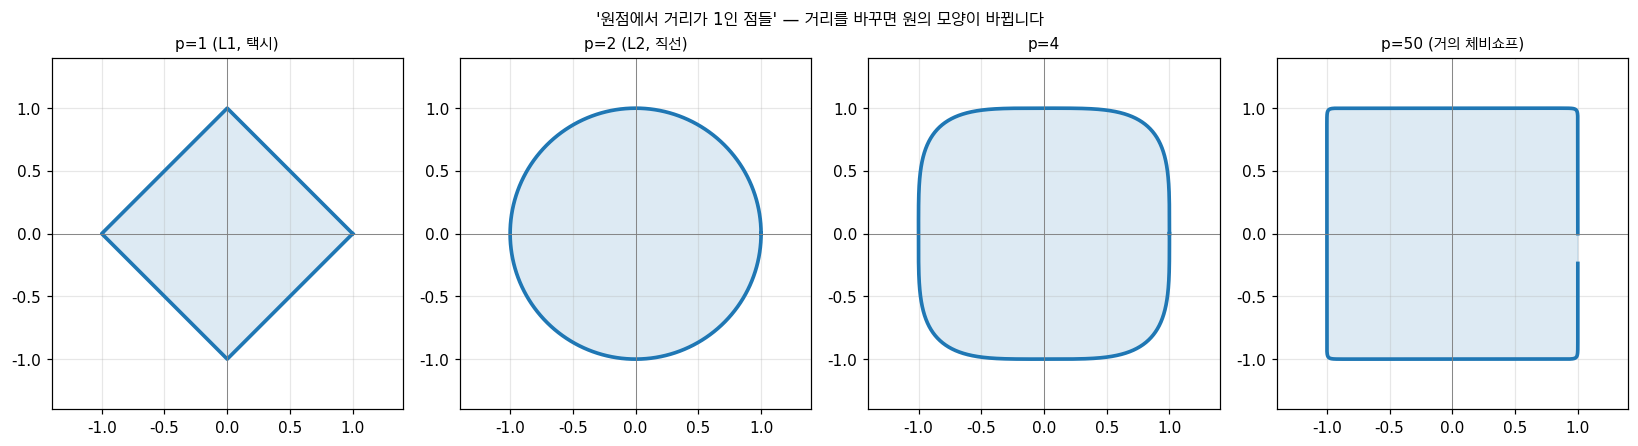

L1은 마름모, L2는 진짜 원, p가 커지면 정사각형에 가까워집니다.
=> KNN에서 '가장 가까운 K개'를 뽑는다는 건, 이 모양을 점점 키워서
   K개가 들어올 때까지 부풀리는 것과 같습니다. 모양이 다르면 이웃도 달라집니다.


In [5]:
# ✨ 추가 — '거리 1인 점들'을 모으면 어떤 모양일까요
각 = np.linspace(0, 2*np.pi, 800)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.9))
for a_, p, 이름 in zip(ax, [1, 2, 4, 50],
                       ["p=1 (L1, 택시)", "p=2 (L2, 직선)", "p=4", "p=50 (거의 체비쇼프)"]):
    # |x|^p + |y|^p = 1 을 매개변수로 그립니다
    c, s = np.cos(각), np.sin(각)
    x = np.sign(c) * np.abs(c) ** (2 / p)
    y = np.sign(s) * np.abs(s) ** (2 / p)
    a_.plot(x, y, lw=2.4, c="tab:blue")
    a_.fill(x, y, alpha=0.15, color="tab:blue")
    a_.set_title(이름, fontsize=10)
    a_.set_xlim(-1.4, 1.4); a_.set_ylim(-1.4, 1.4)
    a_.set_aspect("equal"); a_.grid(alpha=0.3)
    a_.axhline(0, c="gray", lw=0.6); a_.axvline(0, c="gray", lw=0.6)
plt.suptitle("'원점에서 거리가 1인 점들' — 거리를 바꾸면 원의 모양이 바뀝니다", fontsize=11)
plt.tight_layout(); plt.show()

print("L1은 마름모, L2는 진짜 원, p가 커지면 정사각형에 가까워집니다.")
print("=> KNN에서 '가장 가까운 K개'를 뽑는다는 건, 이 모양을 점점 키워서")
print("   K개가 들어올 때까지 부풀리는 것과 같습니다. 모양이 다르면 이웃도 달라집니다.")

---

## 2️⃣ 🔨 KNN 만들기

> 🔗 **앞 절과 이어서** — 1절에서 거리를 정했습니다. "가깝다"가 생겼으니
> 이제 0절의 알고리즘(거리 재기 → 정렬 → K개 뽑기 → 투표)을 **그대로 코드로 옮길 수 있습니다.**

> 📗 **원문** — "Build It: Step 2"

이제 만듭니다. 분류와 회귀, 가중 투표까지 한 클래스에 넣습니다.

```python
class KNN:
    def __init__(self, k=5, distance_fn=l2_distance, weighted=False,
                 task="classification"):
        ...
    def fit(self, X, y):        # 그냥 저장만 합니다
        self.X_train = X
        self.y_train = y
```

> 🔎 `fit`이 **저장만 합니다.** 이게 KNN의 정체입니다. 9절에서 다시 이야기합니다.

In [6]:
# 📗 원문 Step 2 — KNN (분류 + 회귀 + 가중 투표)
class KNN:
    def __init__(self, k=5,거리함수=None, 가중=False, 작업="분류"):
        self.k = k
        self.거리함수 = 거리함수 or L2거리
        self.가중 = 가중
        self.작업 = 작업

    def 학습(self, X, y):
        # 진짜로 저장만 합니다. 계산이 하나도 없어요
        self.X훈련 = np.asarray(X, dtype=float)
        self.y훈련 = np.asarray(y)
        return self

    def _한점예측(self, x):
        거리 = np.array([self.거리함수(x, 점) for 점 in self.X훈련])
        가까운 = np.argsort(거리)[:self.k]
        이웃답 = self.y훈련[가까운]
        무게 = 1.0 / (거리[가까운] + 1e-10) if self.가중 else np.ones(self.k)

        if self.작업 == "분류":
            표 = {}
            for 답, w in zip(이웃답, 무게):
                표[답] = 표.get(답, 0.0) + w
            return max(표.items(), key=lambda kv: kv[1])[0]
        return float((무게 * 이웃답).sum() / 무게.sum())

    def 예측(self, X):
        return np.array([self._한점예측(np.asarray(x, dtype=float)) for x in X])

    def 점수(self, X, y):
        예측값 = self.예측(X)
        if self.작업 == "분류":
            return float(np.mean(예측값 == np.asarray(y)))
        return float(1 - ((예측값 - y)**2).sum() / ((y - y.mean())**2).sum())   # R²

print("KNN 준비 완료")

KNN 준비 완료


> ✨ **추가** — 위 구현은 이웃을 찾을 때 **파이썬 for 문**으로 거리를 하나씩 잽니다.
> 읽기는 쉬운데 느립니다. 아래는 **넘파이로 한 번에** 계산하는 버전입니다.
> 뒤에서 격자 수만 개에 예측할 일이 있어서, 그때 이걸 씁니다.

In [7]:
# ✨ 추가 — 같은 KNN인데 넘파이로 한 번에 계산합니다 (도전 과제 6번의 답)
class 빠른KNN:
    def __init__(self, k=5, 가중=False, 작업="분류", 엡실론=1e-10):
        self.k = k
        self.가중 = 가중
        self.작업 = 작업
        self.엡실론 = 엡실론      # 1/(거리+엡실론). 크게 잡으면 더 부드러워집니다

    def 학습(self, X, y):
        self.X훈련 = np.asarray(X, dtype=float)
        self.y훈련 = np.asarray(y)
        self.클래스 = np.unique(self.y훈련)
        return self

    def _거리행렬(self, X):
        # ||a-b||² = ||a||² + ||b||² - 2a·b  로 모든 쌍을 한 번에
        X = np.asarray(X, dtype=float)
        제곱 = ((X**2).sum(1)[:, None] + (self.X훈련**2).sum(1)[None, :]
                - 2 * (X @ self.X훈련.T))
        return np.sqrt(np.maximum(제곱, 0))

    def 예측(self, X):
        D = self._거리행렬(X)
        k = min(self.k, D.shape[1])
        가까운 = np.argpartition(D, k-1, axis=1)[:, :k]          # 부분 정렬이라 더 빠릅니다
        이웃거리 = np.take_along_axis(D, 가까운, axis=1)
        무게 = 1.0/(이웃거리 + self.엡실론) if self.가중 else np.ones_like(이웃거리)

        if self.작업 == "회귀":
            이웃값 = self.y훈련[가까운]
            return (무게 * 이웃값).sum(1) / 무게.sum(1)
        # 분류: 클래스별로 무게를 더해서 가장 큰 클래스를 고릅니다
        이웃답 = self.y훈련[가까운]
        점수 = np.stack([np.where(이웃답 == c, 무게, 0.0).sum(1) for c in self.클래스], axis=1)
        return self.클래스[점수.argmax(1)]

    def 점수(self, X, y):
        예측값 = self.예측(X)
        if self.작업 == "분류":
            return float(np.mean(예측값 == np.asarray(y)))
        return float(1 - ((예측값 - y)**2).sum() / ((y - y.mean())**2).sum())

print("빠른 KNN 준비 완료")

빠른 KNN 준비 완료


In [8]:
# 잘 되는지 확인합니다 (0절의 라면/피자 데이터)
확인 = KNN(k=3).학습(훈련점, 훈련답)
print("질문점 [2.5, 2.5] 예측:", 확인.예측([[2.5, 2.5]])[0])
print("질문점 [5.2, 5.0] 예측:", 확인.예측([[5.2, 5.0]])[0])

# 세 덩어리 데이터를 만들어 진짜로 붙여 봅니다
def 세덩어리(시드, n=300):
    r = np.random.default_rng(시드)
    중심 = np.array([[0.0, 0.0], [3.0, 3.0], [3.0, -1.5]])
    라벨 = r.integers(0, 3, n)
    X = 중심[라벨] + r.normal(0, 1.0, size=(n, 2))
    return X, 라벨

X, y = 세덩어리(0, 300)
Xte, yte = 세덩어리(1, 300)

내KNN = KNN(k=5).학습(X, y)
print(f"\n직접 만든 KNN (K=5) 테스트 정확도: {내KNN.점수(Xte, yte):.1%}")

from sklearn.neighbors import KNeighborsClassifier
sk = KNeighborsClassifier(n_neighbors=5).fit(X, y)
print(f"sklearn KNN     (K=5) 테스트 정확도: {sk.score(Xte, yte):.1%}")

빠른것 = 빠른KNN(k=5).학습(X, y)
t0 = time.time(); 느린답 = 내KNN.예측(Xte);   느린시간 = time.time() - t0
t0 = time.time(); 빠른답 = 빠른것.예측(Xte);  빠른시간 = time.time() - t0
print(f"빠른 KNN        (K=5) 테스트 정확도: {빠른것.점수(Xte, yte):.1%}")
print(f"\n세 구현의 예측이 모두 같은 비율: "
      f"{np.mean((느린답 == sk.predict(Xte)) & (느린답 == 빠른답)):.1%}")
print(f"for 문 버전 {느린시간*1000:.1f}ms  vs  넘파이 버전 {빠른시간*1000:.1f}ms"
      f"  ({느린시간/max(빠른시간,1e-9):.0f}배 빠름)")

질문점 [2.5, 2.5] 예측: 🍜라면
질문점 [5.2, 5.0] 예측: 🍕피자

직접 만든 KNN (K=5) 테스트 정확도: 93.0%
sklearn KNN     (K=5) 테스트 정확도: 93.0%
빠른 KNN        (K=5) 테스트 정확도: 93.0%

세 구현의 예측이 모두 같은 비율: 100.0%
for 문 버전 119.5ms  vs  넘파이 버전 1.5ms  (78배 빠름)


---

## 3️⃣ 🔑 K를 몇으로 할까

> 🔗 **앞 절과 이어서** — 2절에서 KNN을 다 만들었습니다. 그런데 `k=5`는 제가 그냥 정한 값이었죠.
> **KNN에는 학습할 파라미터가 없습니다.** 그러니 조절할 게 K 하나뿐입니다.
> 이 하나가 과적합과 과소적합을 전부 결정합니다.

> 📗 **원문** — "Choosing K"

K는 KNN의 **유일한 하이퍼파라미터**입니다. 그리고 편향-분산 맞바꿈을 직접 조종합니다.

| K | 무슨 일이 벌어지나 |
| --- | --- |
| **K = 1** | 경계가 점 하나하나를 따라갑니다. 훈련 오차 0. **과적합** |
| **작은 K (3~5)** | 지역 구조에 민감. 복잡한 경계를 잡을 수 있음 |
| **큰 K** | 경계가 매끄러워짐. 잡음에 강함. **과소적합 위험** |
| **K = N** | 모든 점에 대해 다수 클래스만 답함. **최대 편향** |

### 📗 시작점

> 원문: "A common starting point is K = sqrt(N)."
> 그리고 **이진 분류에서는 홀수 K**를 쓰세요. 동점이 안 나오게요.

### 🧸 왜 K=1이 과적합인가요?

훈련 데이터로 시험을 보면, 자기 자신이 **거리 0인 이웃**으로 뽑힙니다.
자기가 자기한테 물어보는 거죠. **당연히 100%입니다.** 아무 의미가 없어요.

> ⚠️ 그래서 K=1의 훈련 정확도 100%는 **성능이 아니라 착시**입니다.
> 1단원에서 만들었던 '외우기만 하는 학습기'와 정확히 같은 함정입니다.

> ✨ **추가** — 원문 연습문제 1번을 풉니다. K를 바꿔 가며 경계와 정확도를 봅니다.

In [9]:
# ✨ 추가 — 원문 연습문제 1번: K에 따른 훈련/테스트 정확도
print(f"{'K':>6}{'훈련 정확도':>13}{'테스트 정확도':>15}   상태")
print("-" * 55)
K결과 = []
for K in [1, 3, 5, 11, 21, 51, 101, len(X)]:
    m = 빠른KNN(k=K).학습(X, y)
    K결과.append((K, m.점수(X, y), m.점수(Xte, yte)))

최고K = max(K결과, key=lambda r: r[2])[0]
최고점 = max(r[2] for r in K결과)
for K, tr, te in K결과:
    if K == 1:
        상태 = "훈련 100%는 착시입니다 (자기 자신이 이웃)"
    elif K == len(X):
        상태 = "K=N. 그냥 다수 클래스만 답합니다"
    elif K == 최고K:
        상태 = "<- 테스트가 가장 좋음"
    elif abs(te - 최고점) <= 0.01:
        상태 = "거의 비슷 (이 구간은 K에 둔감합니다)"
    elif K < 최고K:
        상태 = "경계가 너무 들쭉날쭉 (과적합 쪽)"
    else:
        상태 = "경계가 너무 뭉개짐 (과소적합 쪽)"
    print(f"{K:>6}{tr:>13.1%}{te:>15.1%}   {상태}")

print(f"\n원문이 권하는 시작점 K = √N = √{len(X)} ≈ {int(round(math.sqrt(len(X))))}")
루트K = int(round(math.sqrt(len(X))))
루트점 = 빠른KNN(k=루트K).학습(X, y).점수(Xte, yte)
print(f"실제로 가장 좋았던 K = {최고K} ({최고점:.1%})")
print(f"√N 로 잡았을 때        = {루트점:.1%}  (차이 {루트점-최고점:+.1%})")
print("=> 딱 맞진 않지만 아주 가깝습니다. 어디서 찾기 시작할지는 알려 주는 셈이죠.")
print("   그리고 표 가운데 구간(K=5~101)은 결과가 거의 안 변합니다.")
print("   K는 '대충 맞으면 되는' 손잡이입니다. 극단(K=1, K=N)만 피하면 됩니다.")

     K       훈련 정확도        테스트 정확도   상태
-------------------------------------------------------
     1       100.0%          92.7%   훈련 100%는 착시입니다 (자기 자신이 이웃)
     3        96.0%          94.7%   <- 테스트가 가장 좋음
     5        95.3%          93.0%   경계가 너무 뭉개짐 (과소적합 쪽)
    11        95.7%          94.0%   거의 비슷 (이 구간은 K에 둔감합니다)
    21        95.7%          94.0%   거의 비슷 (이 구간은 K에 둔감합니다)
    51        95.3%          94.0%   거의 비슷 (이 구간은 K에 둔감합니다)
   101        95.0%          94.0%   거의 비슷 (이 구간은 K에 둔감합니다)
   300        38.3%          36.3%   K=N. 그냥 다수 클래스만 답합니다

원문이 권하는 시작점 K = √N = √300 ≈ 17
실제로 가장 좋았던 K = 3 (94.7%)
√N 로 잡았을 때        = 94.0%  (차이 -0.7%)
=> 딱 맞진 않지만 아주 가깝습니다. 어디서 찾기 시작할지는 알려 주는 셈이죠.
   그리고 표 가운데 구간(K=5~101)은 결과가 거의 안 변합니다.
   K는 '대충 맞으면 되는' 손잡이입니다. 극단(K=1, K=N)만 피하면 됩니다.


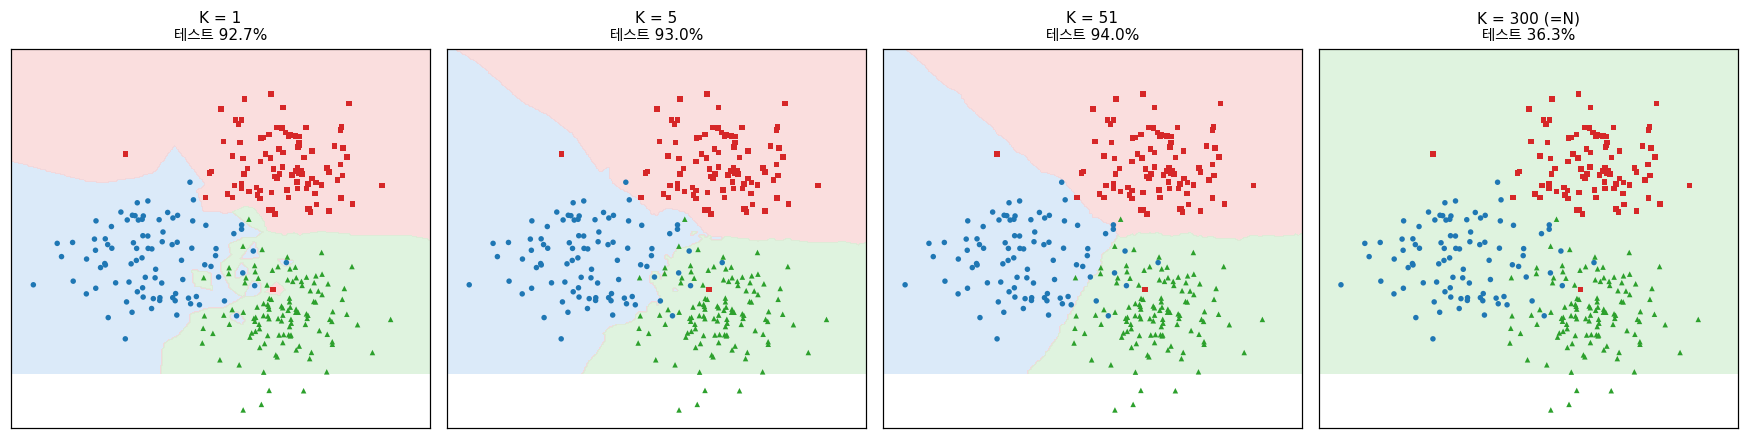

K=1  : 경계가 톱니처럼 들쭉날쭉합니다. 점 하나하나를 다 따라갑니다.
K=5  : 적당히 매끄럽습니다.
K=51 : 더 매끄럽습니다. 작은 무늬는 사라졌습니다.
K=N  : 경계가 아예 없습니다. 전체 다수 클래스 하나만 답합니다.

💡 K=1의 경계를 보로노이 다이어그램이라고 부릅니다. 용어 사전에 나옵니다.


In [10]:
# ✨ 추가 — K에 따라 경계가 어떻게 변하는지 (원문 연습문제 1번)
g = np.linspace(-3.5, 6.5, 260)
G1, G2 = np.meshgrid(g, g)
격자 = np.c_[G1.ravel(), G2.ravel()]

fig, ax = plt.subplots(1, 4, figsize=(16, 4.1))
for a_, K in zip(ax, [1, 5, 51, len(X)]):
    m = 빠른KNN(k=K).학습(X, y)
    Z = m.예측(격자).reshape(G1.shape)
    a_.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=["#cfe3f7", "#f9d3d3", "#d5f0d5"], alpha=0.75)
    for 라벨, (c, mk) in enumerate([("tab:blue", "o"), ("tab:red", "s"), ("tab:green", "^")]):
        a_.scatter(X[y == 라벨, 0], X[y == 라벨, 1], c=c, s=13, marker=mk, edgecolors="none")
    꼬리 = " (=N)" if K == len(X) else ""
    a_.set_title(f"K = {K}{꼬리}\n테스트 {m.점수(Xte, yte):.1%}", fontsize=10)
    a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.show()

print("K=1  : 경계가 톱니처럼 들쭉날쭉합니다. 점 하나하나를 다 따라갑니다.")
print("K=5  : 적당히 매끄럽습니다.")
print("K=51 : 더 매끄럽습니다. 작은 무늬는 사라졌습니다.")
print("K=N  : 경계가 아예 없습니다. 전체 다수 클래스 하나만 답합니다.")
print("\n💡 K=1의 경계를 보로노이 다이어그램이라고 부릅니다. 용어 사전에 나옵니다.")

---

## 4️⃣ 어떤 거리를 써야 하나

> 🔗 **앞 절과 이어서** — 3절에서 K를 골랐습니다. 그런데 손잡이가 하나 더 있었죠.
> 1절에서 거리 함수를 네 개 만들어 놓고 **아무 근거 없이 L2를 기본값으로 썼습니다.**
> 여기서 그 선택이 결과를 얼마나 바꾸는지 확인합니다.

> 📗 **원문** — "Which metric to use depends on the data"

| 데이터 종류 | 추천 거리 | 왜 |
| --- | --- | --- |
| 숫자 특징, 비슷한 스케일 | **L2 (유클리드)** | 기본값. 공간 데이터에 잘 맞음 |
| 숫자 특징, 이상치 있음 | **L1 (맨해튼)** | 큰 차이를 제곱해서 키우지 않음 |
| 텍스트 임베딩 | **코사인** | **크기는 잡음, 방향이 의미** |
| 고차원 희소 데이터 | 코사인 또는 L1 | L2는 차원의 저주에 약함 |
| 여러 종류가 섞임 | 직접 만든 거리 | 특징별로 다른 척도를 조합 |

1절에서 코사인이 문서 길이를 무시한다는 걸 봤습니다. 이제 **진짜 분류 문제**로 확인합니다.

> ✨ **추가** — 원문 연습문제 3번을 풉니다. 길이가 제각각인 문서에서 코사인이 정말 이기는지.

In [11]:
# ✨ 추가 — 원문 연습문제 3번: 텍스트에서 코사인이 이기는 이유
# 단어 40개짜리 어휘를 만듭니다. 주제 A는 앞쪽 단어, 주제 B는 뒤쪽 단어를 주로 씁니다
def 문서데이터(시드, n=200, 어휘=40):
    r = np.random.default_rng(시드)
    주제 = r.integers(0, 2, n)
    문서들 = []
    for t in 주제:
        확률 = np.full(어휘, 0.2)
        # 주제 차이는 '살짝'만 줍니다. 실제 문서도 주제어 몇 개만 다르지 나머지는 비슷하니까요
        if t == 0:
            확률[:어휘//2] += 0.02                           # 주제 A 단어를 조금 더 씀
        else:
            확률[어휘//2:] += 0.02                           # 주제 B 단어를 조금 더 씀
        확률 = 확률 / 확률.sum()
        길이 = int(r.integers(100, 8000))                   # ⭐ 문서 길이가 100~8000으로 제각각
        문서들.append(r.multinomial(길이, 확률).astype(float))
    return np.array(문서들), 주제

X문서, y문서 = 문서데이터(0, 200)
X문서te, y문서te = 문서데이터(1, 200)

print(f"문서 길이 범위: {int(X문서.sum(1).min())} ~ {int(X문서.sum(1).max())} 단어")
print(f"짧은 주제A 문서와 긴 주제A 문서는 '내용은 같은데 크기가 다릅니다'\n")

print(f"{'거리':<12}{'테스트 정확도':>14}")
print("-" * 28)
거리표 = []
for 이름, fn in [("L2 (유클리드)", L2거리), ("L1 (맨해튼)", L1거리), ("코사인", 코사인거리)]:
    m = KNN(k=5, 거리함수=fn).학습(X문서, y문서)
    점 = m.점수(X문서te, y문서te)
    거리표.append((이름, 점))
    print(f"{이름:<11}{점:>15.1%}")

승자 = max(거리표, key=lambda r: r[1])
print(f"\n=> 승자: {승자[0]} ({승자[1]:.1%})")
print("   L2는 '긴 문서끼리 비슷하다'고 착각합니다. 주제가 달라도 둘 다 크니까요.")
print("   코사인은 크기를 나눠 버려서 '단어 비율'만 봅니다. 그게 곧 주제입니다.")

문서 길이 범위: 165 ~ 7897 단어
짧은 주제A 문서와 긴 주제A 문서는 '내용은 같은데 크기가 다릅니다'

거리                 테스트 정확도
----------------------------
L2 (유클리드)            89.0%
L1 (맨해튼)             88.0%
코사인                  97.5%

=> 승자: 코사인 (97.5%)
   L2는 '긴 문서끼리 비슷하다'고 착각합니다. 주제가 달라도 둘 다 크니까요.
   코사인은 크기를 나눠 버려서 '단어 비율'만 봅니다. 그게 곧 주제입니다.


In [12]:
# ✨ 추가 — L2가 왜 속는지 직접 봅니다
짧은A = np.argsort(X문서.sum(1))[:1][0]              # 가장 짧은 문서
긴것들 = np.argsort(X문서.sum(1))[-2:]               # 가장 긴 문서 2개

print(f"기준 문서: 길이 {int(X문서[짧은A].sum())}단어, 주제 {y문서[짧은A]}\n")
print(f"{'비교 대상':<28}{'L2 거리':>10}{'코사인 거리':>13}")
print("-" * 52)
for i in 긴것들:
    같은주제 = "같은 주제" if y문서[i] == y문서[짧은A] else "다른 주제"
    print(f"길이 {int(X문서[i].sum()):>4}단어, 주제 {y문서[i]} ({같은주제}){'':<6}"
          f"{L2거리(X문서[짧은A], X문서[i]):>10.1f}{코사인거리(X문서[짧은A], X문서[i]):>13.4f}")

# 같은 주제 중 길이가 비슷한 문서
같은주제들 = np.where(y문서 == y문서[짧은A])[0]
비슷한길이 = 같은주제들[np.argsort(np.abs(X문서[같은주제들].sum(1) - X문서[짧은A].sum()))[1]]
print(f"길이 {int(X문서[비슷한길이].sum()):>4}단어, 주제 {y문서[비슷한길이]} (같은 주제){'':<6}"
      f"{L2거리(X문서[짧은A], X문서[비슷한길이]):>10.1f}"
      f"{코사인거리(X문서[짧은A], X문서[비슷한길이]):>13.4f}")

print("\n=> L2 거리는 '길이 차이'에 압도됩니다. 주제가 같아도 길면 멀다고 나옵니다.")
print("   코사인은 같은 주제면 길이와 상관없이 작은 값이 나옵니다.")
print("\n🏭 실무 메모: 임베딩 검색(RAG, 벡터 DB)이 코사인 유사도를 쓰는 이유가 정확히 이겁니다.")

기준 문서: 길이 165단어, 주제 0

비교 대상                            L2 거리       코사인 거리
----------------------------------------------------
길이 7862단어, 주제 1 (다른 주제)          1220.0       0.0860
길이 7897단어, 주제 0 (같은 주제)          1227.3       0.0817
길이  205단어, 주제 0 (같은 주제)            16.9       0.1102

=> L2 거리는 '길이 차이'에 압도됩니다. 주제가 같아도 길면 멀다고 나옵니다.
   코사인은 같은 주제면 길이와 상관없이 작은 값이 나옵니다.

🏭 실무 메모: 임베딩 검색(RAG, 벡터 DB)이 코사인 유사도를 쓰는 이유가 정확히 이겁니다.


---

## 5️⃣ 가중 KNN — 가까운 이웃에게 더 큰 표를

> 🔗 **앞 절과 이어서** — 여기까지 K와 거리를 골랐습니다. 그런데 0절의 규칙에 이상한 점이 하나 있습니다.
> **이웃 K명에게 전부 똑같은 한 표**를 줬다는 거예요. 바로 옆에 붙은 이웃과 저 멀리 있는 이웃이 같은 힘을 갖습니다.
> 이걸 고치면, 3절에서 애먹었던 **K 고르기 부담까지 줄어듭니다.**

> 📗 **원문** — "Weighted KNN"

기본 KNN은 이웃 K명에게 **똑같은 한 표**를 줍니다. 그런데 이상하지 않나요?

> 📗 원문: "a neighbor at distance 0.1 should matter more than one at distance 5.0"
> (거리 0.1짜리 이웃이 거리 5.0짜리 이웃보다 중요해야 합니다.)

**거리 가중 KNN**은 거리에 반비례해서 표의 무게를 줍니다.

$$w_i = \frac{1}{d_i + \epsilon}$$

- 분류 → **가중 투표**
- 회귀 → **가중 평균** $\ \sum w_i y_i / \sum w_i$

$\epsilon$은 **질문점이 훈련점과 정확히 같을 때 0으로 나누는 걸 막습니다.**

### 📗 좋은 점

> "Weighted KNN is less sensitive to the choice of K."

K를 크게 잡아도 **먼 이웃은 어차피 표가 거의 없어서** 결과가 잘 안 망가집니다.
K 고르기 부담이 줄어드는 거죠.

> ✨ **추가** — 'K를 키워도 덜 망가진다'가 정말인지 잽니다.

In [13]:
# ✨ 추가 — K를 키울 때 가중/비가중이 얼마나 버티는지
print(f"{'K':>6}{'기본 KNN':>12}{'가중 KNN':>12}{'차이':>10}")
print("-" * 42)
가중표 = []
for K in [1, 5, 21, 51, 101, 201]:
    기본 = 빠른KNN(k=K, 가중=False).학습(X, y).점수(Xte, yte)
    가중 = 빠른KNN(k=K, 가중=True).학습(X, y).점수(Xte, yte)
    가중표.append((K, 기본, 가중))
    print(f"{K:>6}{기본:>12.1%}{가중:>12.1%}{가중-기본:>+10.1%}")

시작K, 끝K = 가중표[1][0], 가중표[-1][0]
print(f"\nK={시작K} -> K={끝K} 로 K를 키웠을 때")
print(f"  기본 KNN: {가중표[1][1]:.1%} -> {가중표[-1][1]:.1%}  ({가중표[-1][1]-가중표[1][1]:+.1%}p)")
print(f"  가중 KNN: {가중표[1][2]:.1%} -> {가중표[-1][2]:.1%}  ({가중표[-1][2]-가중표[1][2]:+.1%}p)")
print(f"\n=> K가 작을 땐 둘이 똑같습니다. 이웃이 몇 개 없으니 무게를 줘도 차이가 없어요.")
print(f"   그런데 K를 {끝K}까지 키우면 기본 KNN이 무너집니다. "
      f"엉뚱하게 먼 이웃까지 한 표씩 갖게 되니까요.")
print(f"   가중 KNN은 버팁니다. 먼 이웃은 표가 1/거리 라서 거의 없는 거나 마찬가지거든요.")
print(f"   원문이 말한 '가중 KNN은 K 선택에 덜 민감하다'가 이겁니다.")

     K      기본 KNN      가중 KNN        차이
------------------------------------------
     1       92.7%       92.7%     +0.0%
     5       93.0%       93.0%     +0.0%
    21       94.0%       94.0%     +0.0%
    51       94.0%       93.7%     -0.3%
   101       94.0%       94.0%     +0.0%
   201       85.3%       94.3%     +9.0%

K=5 -> K=201 로 K를 키웠을 때
  기본 KNN: 93.0% -> 85.3%  (-7.7%p)
  가중 KNN: 93.0% -> 94.3%  (+1.3%p)

=> K가 작을 땐 둘이 똑같습니다. 이웃이 몇 개 없으니 무게를 줘도 차이가 없어요.
   그런데 K를 201까지 키우면 기본 KNN이 무너집니다. 엉뚱하게 먼 이웃까지 한 표씩 갖게 되니까요.
   가중 KNN은 버팁니다. 먼 이웃은 표가 1/거리 라서 거의 없는 거나 마찬가지거든요.
   원문이 말한 '가중 KNN은 K 선택에 덜 민감하다'가 이겁니다.


---

## 6️⃣ 스케일링은 선택이 아닙니다

> 🔗 **여기서 방향이 바뀝니다** — 5절까지는 "KNN을 잘 쓰는 법"이었습니다.
> 지금부터 세 절(6·7·8)은 **KNN이 깨지는 지점**입니다. 첫 번째는 **단위**예요.
> KNN은 거리로만 판단하니까, 어떤 특징의 숫자가 크면 **그 특징이 곧 정답이 되어 버립니다.**

> 📗 **원문** — "Build It: Step 4"

> "A feature ranging from 0 to 1000 will dominate a feature ranging from 0 to 1."
> (0~1000 범위 특징이 0~1 범위 특징을 완전히 눌러 버립니다.)

### 🧸 비유 — 키와 나이로 사람 찾기

두 사람이 얼마나 비슷한지를 **키(cm)**와 **나이(살)**로 재려고 합니다.

- 사람 A: 키 170, 나이 20
- 사람 B: 키 171, 나이 60

거리를 그냥 재면 $\sqrt{1^2 + 40^2} = 40.01$. 나이 차이가 다 먹었습니다.

그런데 키를 **미터**로 바꾸면? 1.70 vs 1.71 → $\sqrt{0.01^2 + 40^2} = 40.0$. 이번엔 키가 아예 안 보입니다.

> **단위를 바꿨을 뿐인데 '가깝다'의 뜻이 바뀝니다.** 이건 고장입니다.

**해결: 표준화** — 모든 특징을 평균 0, 표준편차 1로 맞춥니다.
그러면 "이 특징 기준으로 몇 칸이나 특이한가"라는 **공통 단위**가 생깁니다.

In [14]:
# 📗 원문 Step 4 — 표준화
def 표준화(X):
    평균 = X.mean(axis=0)
    표준편차 = np.maximum(X.std(axis=0), 1e-10)
    return (X - 평균) / 표준편차, 평균, 표준편차

# ✨ 추가 — 단위를 망가뜨려 놓고 KNN을 돌려 봅니다
X망 = X.copy();   X망[:, 1] *= 300      # 두 번째 특징만 300배 (예: m -> mm)
X망te = Xte.copy(); X망te[:, 1] *= 300

안한거 = 빠른KNN(k=5).학습(X망, y).점수(X망te, yte)
Xs, 평균, 표준 = 표준화(X망)
한거 = 빠른KNN(k=5).학습(Xs, y).점수((X망te - 평균) / 표준, yte)

print(f"{'':<22}{'테스트 정확도':>14}")
print("-" * 38)
print(f"{'스케일링 안 함':<20}{안한거:>15.1%}")
print(f"{'스케일링 함':<21}{한거:>15.1%}")
print(f"\n원래 데이터(단위 안 망가뜨림) : {빠른KNN(k=5).학습(X, y).점수(Xte, yte):.1%}")
print("\n=> 값 자체는 하나도 안 바꾸고 '단위'만 바꿨는데 성능이 무너집니다.")
print("   KNN은 거리로만 판단하니까, 스케일이 곧 '중요도'가 되어 버립니다.")
print("   5단원 SVM도 같은 이유로 스케일링이 필수였죠. 거리를 쓰는 모델의 공통 약점입니다.")

                             테스트 정확도
--------------------------------------
스케일링 안 함                      76.7%
스케일링 함                         94.0%

원래 데이터(단위 안 망가뜨림) : 93.0%

=> 값 자체는 하나도 안 바꾸고 '단위'만 바꿨는데 성능이 무너집니다.
   KNN은 거리로만 판단하니까, 스케일이 곧 '중요도'가 되어 버립니다.
   5단원 SVM도 같은 이유로 스케일링이 필수였죠. 거리를 쓰는 모델의 공통 약점입니다.


---

## 7️⃣ 🔑 차원의 저주

> 🔗 **앞 절과 이어서** — 6절에서 단위를 맞췄습니다. 문제가 다 풀렸을까요?
> 아닙니다. **단위가 완벽해도 차원이 높으면 거리 자체가 의미를 잃습니다.**
> 이건 튜닝으로 못 고치는, KNN의 근본적인 한계입니다.

> 📗 **원문** — "The curse of dimensionality"

> "This is not a vague concern. It is a mathematical fact."
> (막연한 걱정이 아니라 수학적 사실입니다.)

차원이 높아지면 KNN이 **망가집니다.** 원문은 세 가지 이유를 듭니다.

### 📗 문제 1 — 거리가 다 비슷해집니다

차원이 늘어날수록 **가장 먼 점과 가장 가까운 점의 거리 비율이 1에 수렴**합니다.

```
d=2    : 최대거리/최소거리 = 제각각
d=100  : ~1.01
d=1000 : ~1.001
```

**모든 점이 똑같이 멀면 '가장 가깝다'는 말 자체가 의미가 없습니다.**

### 📗 문제 2 — 부피가 폭발합니다

전체 데이터의 1%를 담으려면, 차원이 높을수록 **훨씬 넓게 훑어야** 합니다.
"이웃"이 사실상 공간 전체가 되어 버립니다.

### 📗 문제 3 — 모서리가 다 먹습니다

$d$차원 정육면체의 부피는 **가운데가 아니라 모서리 쪽에 몰립니다.**
정육면체에 내접하는 공의 부피 비율은 $d$가 커질수록 **0으로 갑니다.**

### 🧸 비유 — 넓은 운동장에 흩어진 사람들

10평 방에 사람 100명이 있으면 "가장 가까운 사람"이 분명합니다.
축구장에 100명을 흩뿌리면? **다들 저 멀리 있습니다.** 누가 제일 가까운지 의미가 없어요.

차원을 하나 늘릴 때마다 공간이 이런 식으로 넓어집니다.

### 📗 실무 결론

> "KNN works well up to about 20-50 features."

그 이상이면 **먼저 차원을 줄여야 합니다** (PCA, UMAP, t-SNE).

> ✨ **추가** — 원문 연습문제 2번을 풉니다. 세 문제를 전부 직접 재 보겠습니다.

In [15]:
# ✨ 추가 — 원문 연습문제 2번: 차원별 최대/최소 거리 비율
r = np.random.default_rng(0)
차원들 = [2, 5, 10, 50, 100, 500, 1000]
비율들, 상대차 = [], []

print(f"{'차원 d':>8}{'최소 거리':>12}{'최대 거리':>12}{'최대/최소':>12}{'(최대-최소)/최소':>17}")
print("-" * 63)
for d in 차원들:
    점들 = r.uniform(0, 1, size=(500, d))
    질문 = r.uniform(0, 1, size=d)
    거리 = np.sqrt(((점들 - 질문) ** 2).sum(axis=1))
    비율 = 거리.max() / 거리.min()
    비율들.append(비율)
    상대차.append((거리.max() - 거리.min()) / 거리.min())
    print(f"{d:>8}{거리.min():>12.3f}{거리.max():>12.3f}{비율:>12.4f}{상대차[-1]:>17.4f}")

print(f"\n=> d=2에서는 최대가 최소의 {비율들[0]:.1f}배인데,")
print(f"   d={차원들[-1]}에서는 {비율들[-1]:.3f}배입니다. 거의 1이죠.")
print("   '가장 가까운 이웃'과 '가장 먼 점'이 사실상 같은 거리라는 뜻입니다.")
print(f"\n⚠️ 원문은 d=1000에서 ~1.001이라고 적었는데 우리는 {비율들[-1]:.3f}이 나왔습니다.")
print(f"   이 값은 점 개수에 따라 달라집니다 (여기서는 {500}개). 점이 많을수록 최소 거리가 짧아져 비율이 커져요.")
print("   중요한 건 정확한 숫자가 아니라 '차원이 오르면 1로 수렴한다'는 방향입니다.")

    차원 d       최소 거리       최대 거리       최대/최소       (최대-최소)/최소
---------------------------------------------------------------
       2       0.030       1.272     41.7297          40.7297
       5       0.289       1.810      6.2727           5.2727
      10       0.603       1.834      3.0401           2.0401
      50       2.173       3.524      1.6218           0.6218
     100       3.467       4.887      1.4098           0.4098
     500       8.483       9.933      1.1710           0.1710
    1000      12.275      13.621      1.1097           0.1097

=> d=2에서는 최대가 최소의 41.7배인데,
   d=1000에서는 1.110배입니다. 거의 1이죠.
   '가장 가까운 이웃'과 '가장 먼 점'이 사실상 같은 거리라는 뜻입니다.

⚠️ 원문은 d=1000에서 ~1.001이라고 적었는데 우리는 1.110이 나왔습니다.
   이 값은 점 개수에 따라 달라집니다 (여기서는 500개). 점이 많을수록 최소 거리가 짧아져 비율이 커져요.
   중요한 건 정확한 숫자가 아니라 '차원이 오르면 1로 수렴한다'는 방향입니다.


In [16]:
# ✨ 추가 — 문제 2·3도 재 봅니다 (부피 폭발 / 모서리 지배)
print("[문제 2] 전체의 1%를 담으려면 한 변을 얼마나 늘려야 하나")
print(f"{'차원 d':>8}{'필요한 한 변 길이':>18}")
print("-" * 28)
for d in [1, 2, 10, 50, 100]:
    변 = 0.01 ** (1 / d)      # 변^d = 0.01
    print(f"{d:>8}{변:>18.4f}")
print("=> d=100이면 한 변이 0.955입니다. 전체 폭의 95%를 훑어야 겨우 1%가 담깁니다.")
print("   그게 무슨 '이웃'인가요? 거의 전체입니다.\n")

print("[문제 3] 정육면체 안에 내접하는 공의 부피 비율")
print(f"{'차원 d':>8}{'공 부피 / 정육면체 부피':>24}")
print("-" * 34)
for d in [2, 3, 5, 10, 20, 50]:
    # 반지름 1/2 공의 부피 = π^(d/2)/Γ(d/2+1) * (1/2)^d,  정육면체(한 변 1) 부피 = 1
    비 = (math.pi ** (d/2) / math.gamma(d/2 + 1)) * (0.5 ** d)
    print(f"{d:>8}{비:>24.3e}")
print("=> d=50이면 10^-28 수준입니다. 부피가 전부 모서리로 갔습니다.")
print("   가운데(공 안쪽)에는 사실상 아무 점도 없습니다.")

[문제 2] 전체의 1%를 담으려면 한 변을 얼마나 늘려야 하나
    차원 d        필요한 한 변 길이
----------------------------
       1            0.0100
       2            0.1000
      10            0.6310
      50            0.9120
     100            0.9550
=> d=100이면 한 변이 0.955입니다. 전체 폭의 95%를 훑어야 겨우 1%가 담깁니다.
   그게 무슨 '이웃'인가요? 거의 전체입니다.

[문제 3] 정육면체 안에 내접하는 공의 부피 비율
    차원 d          공 부피 / 정육면체 부피
----------------------------------
       2               7.854e-01
       3               5.236e-01
       5               1.645e-01
      10               2.490e-03
      20               2.461e-08
      50               1.537e-28
=> d=50이면 10^-28 수준입니다. 부피가 전부 모서리로 갔습니다.
   가운데(공 안쪽)에는 사실상 아무 점도 없습니다.


     전체 차원       의미 있는 차원      KNN 정확도
----------------------------------------
         2              2        95.2%
         5              2        96.5%
        10              2        95.8%
        20              2        94.2%
        50              2        90.8%
       100              2        88.2%
       500              2        73.8%

=> 정보량은 하나도 안 늘었습니다. 잡음 열만 붙였을 뿐이에요.
   그런데 정확도가 95.2% -> 73.8%로 떨어집니다.
   잡음 차원의 거리가 진짜 신호를 파묻어 버린 겁니다. 이게 차원의 저주입니다.


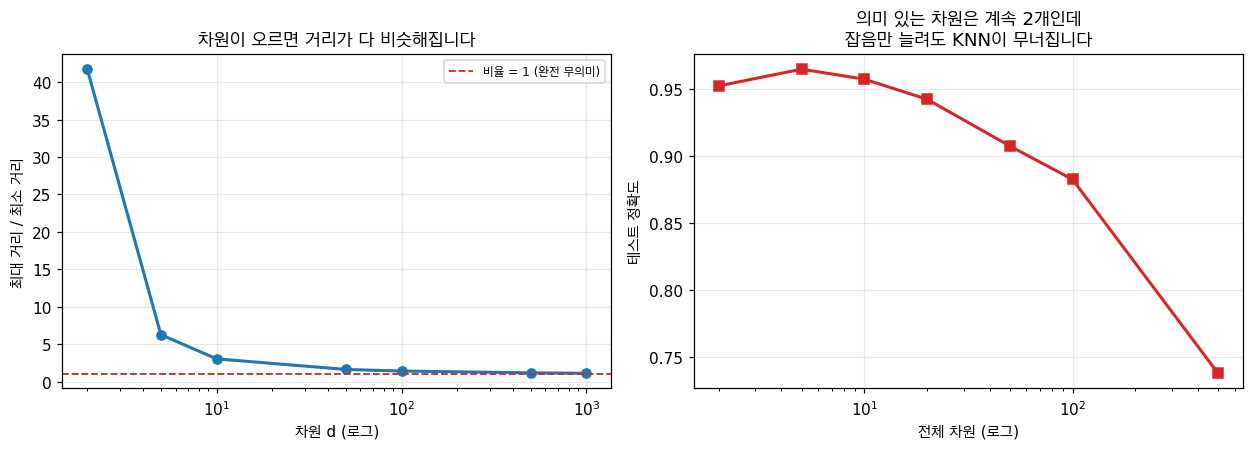

In [17]:
# ✨ 추가 — 그래서 KNN 정확도가 실제로 어떻게 무너지는지
def 차원늘린데이터(시드, n, 잡음차원):
    # 의미 있는 특징은 2개뿐. 나머지는 전부 무의미한 잡음입니다
    r = np.random.default_rng(시드)
    중심 = np.array([[0.0, 0.0], [2.5, 2.5]])
    라벨 = r.integers(0, 2, n)
    X = np.c_[중심[라벨] + r.normal(0, 1.0, size=(n, 2)),
              r.normal(0, 1.0, size=(n, 잡음차원))]
    return X, 라벨

print(f"{'전체 차원':>10}{'의미 있는 차원':>15}{'KNN 정확도':>13}")
print("-" * 40)
저주결과 = []
for 잡음 in [0, 3, 8, 18, 48, 98, 498]:
    Xa, ya = 차원늘린데이터(0, 400, 잡음)
    Xb, yb = 차원늘린데이터(1, 400, 잡음)
    점 = 빠른KNN(k=5).학습(Xa, ya).점수(Xb, yb)
    저주결과.append((2 + 잡음, 점))
    print(f"{2+잡음:>10}{2:>15}{점:>13.1%}")

print(f"\n=> 정보량은 하나도 안 늘었습니다. 잡음 열만 붙였을 뿐이에요.")
print(f"   그런데 정확도가 {저주결과[0][1]:.1%} -> {저주결과[-1][1]:.1%}로 떨어집니다.")
print("   잡음 차원의 거리가 진짜 신호를 파묻어 버린 겁니다. 이게 차원의 저주입니다.")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(차원들, 비율들, "o-", lw=2)
ax[0].axhline(1.0, c="tab:red", ls="--", lw=1.2, label="비율 = 1 (완전 무의미)")
ax[0].set_xscale("log"); ax[0].set_xlabel("차원 d (로그)")
ax[0].set_ylabel("최대 거리 / 최소 거리")
ax[0].set_title("차원이 오르면 거리가 다 비슷해집니다")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot([d for d, _ in 저주결과], [p for _, p in 저주결과], "s-", lw=2, c="tab:red")
ax[1].set_xscale("log"); ax[1].set_xlabel("전체 차원 (로그)")
ax[1].set_ylabel("테스트 정확도")
ax[1].set_title("의미 있는 차원은 계속 2개인데\n잡음만 늘려도 KNN이 무너집니다")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 8️⃣ 🔨 KD-트리로 빠르게 찾기

> 🔗 **앞 절과 이어서** — 이제 정확도 문제는 봤으니 **속도**를 봅니다.
> 그런데 재미있는 일이 벌어집니다. **7절의 차원의 저주가 여기서 다시 나타납니다.**
> 거리가 다 비슷해지면 "이 가지는 안 봐도 된다"고 자를 수가 없어서, **트리가 무용지물이 됩니다.**
> 두 절이 여기서 만납니다.

> 📗 **원문** — "KD-trees: fast nearest neighbor search" + "Build It: Step 3"

무차별 탐색은 질문 하나에 **모든 점과 거리를 잽니다.** $O(n \cdot d)$예요.
데이터가 100만 개면 질문 하나에 100만 번 계산입니다. 너무 느립니다.

**KD-트리**는 공간을 축 방향으로 반씩 쪼갠 이진 트리입니다.

- 깊이 0에서는 **첫 번째 특징**의 중앙값으로 쪼갭니다
- 깊이 1에서는 **두 번째 특징**의 중앙값으로
- 깊이 $i$에서는 $i \bmod d$ 번째 특징으로

### 🧸 비유 — 도서관에서 책 찾기

책 100만 권을 다 확인하면 오래 걸립니다. 그런데 서가에 순서대로 꽂혀 있으면?
**"이 서가는 아예 안 봐도 된다"**고 통째로 건너뛸 수 있습니다.

KD-트리 탐색도 똑같습니다.
1. 질문점이 속한 **잎까지 쭉 내려갑니다** (여기까진 빠릅니다)
2. 올라오면서 **"반대편에 더 가까운 점이 있을 수 있나?"**를 확인합니다
3. **없으면 그 가지를 통째로 건너뜁니다** ← 여기서 시간이 절약됩니다

### ⚠️ 그런데 차원이 높으면 무너집니다

> 📗 원문: "KD-trees degrade to O(n) in high dimensions (d > 20) because the backtracking eliminates fewer and fewer branches."

7절의 차원의 저주 때문입니다. 거리가 다 비슷해지면 **"안 봐도 된다"고 자를 수가 없어요.**
결국 다 뒤지게 되고, 트리 만든 비용만 손해입니다. 8절 끝에서 직접 재 보겠습니다.

In [18]:
# 📗 원문 Step 3 — KD-트리 (원문은 뼈대만 주므로 완성해서 만듭니다)
import heapq

class KD트리:
    def __init__(self, X):
        self.X = np.asarray(X, dtype=float)
        self.뿌리 = self._만들기(np.arange(len(self.X)), 깊이=0)

    def _만들기(self, 번호들, 깊이):
        if len(번호들) == 0:
            return None
        축 = 깊이 % self.X.shape[1]          # 깊이마다 자르는 축을 바꿉니다
        정렬 = 번호들[np.argsort(self.X[번호들, 축])]
        가운데 = len(정렬) // 2
        return {"번호": 정렬[가운데], "축": 축,
                "왼쪽": self._만들기(정렬[:가운데], 깊이 + 1),
                "오른쪽": self._만들기(정렬[가운데 + 1:], 깊이 + 1)}

    def 질의(self, 질문, k=1):
        self.본노드수 = 0
        힙 = []                              # (-거리, 번호) 최대 힙
        self._찾기(self.뿌리, np.asarray(질문, dtype=float), k, 힙)
        결과 = sorted([(-d, i) for d, i in 힙])
        return np.array([d for d, _ in 결과]), np.array([i for _, i in 결과])

    def _찾기(self, 노드, 질문, k, 힙):
        if 노드 is None:
            return
        self.본노드수 += 1
        거리 = math.sqrt(float(((self.X[노드["번호"]] - 질문) ** 2).sum()))
        if len(힙) < k:
            heapq.heappush(힙, (-거리, 노드["번호"]))
        elif 거리 < -힙[0][0]:
            heapq.heapreplace(힙, (-거리, 노드["번호"]))

        축 = 노드["축"]
        축차이 = 질문[축] - self.X[노드["번호"], 축]
        가까운쪽, 먼쪽 = (노드["왼쪽"], 노드["오른쪽"]) if 축차이 < 0 else (노드["오른쪽"], 노드["왼쪽"])
        self._찾기(가까운쪽, 질문, k, 힙)
        # ⭐ 핵심: 반대편에 더 가까운 점이 '있을 수 있을 때만' 건너갑니다
        if len(힙) < k or abs(축차이) < -힙[0][0]:
            self._찾기(먼쪽, 질문, k, 힙)

print("KD-트리 준비 완료")

KD-트리 준비 완료


In [19]:
# 정답이 맞는지 무차별 탐색과 하나하나 대조합니다
r = np.random.default_rng(0)
Xk = r.normal(size=(2000, 2))
질문들 = r.normal(size=(200, 2))

트리 = KD트리(Xk)
맞은개수, 본노드합 = 0, 0
for q in 질문들:
    d트리, i트리 = 트리.질의(q, k=5)
    본노드합 += 트리.본노드수
    전체거리 = np.sqrt(((Xk - q) ** 2).sum(axis=1))
    i무차별 = np.argsort(전체거리)[:5]
    if set(i트리) == set(i무차별):
        맞은개수 += 1

print(f"질문 {len(질문들)}개 중 무차별 탐색과 결과가 똑같은 경우: {맞은개수}개")
print(f"=> KD-트리는 근사가 아니라 '정확한' 알고리즘입니다. 빠르기만 한 게 아니에요.\n")
print(f"질문 하나당 실제로 살펴본 노드 수: 평균 {본노드합/len(질문들):.1f}개 (전체 {len(Xk)}개 중)")
print(f"   전체의 {본노드합/len(질문들)/len(Xk):.1%}만 보고 답을 찾았습니다.")
print(f"   log2({len(Xk)}) ≈ {math.log2(len(Xk)):.1f} 이니, O(log n)보다는 크지만 O(n)보다 훨씬 작습니다.")

질문 200개 중 무차별 탐색과 결과가 똑같은 경우: 200개
=> KD-트리는 근사가 아니라 '정확한' 알고리즘입니다. 빠르기만 한 게 아니에요.

질문 하나당 실제로 살펴본 노드 수: 평균 31.9개 (전체 2000개 중)
   전체의 1.6%만 보고 답을 찾았습니다.
   log2(2000) ≈ 11.0 이니, O(log n)보다는 크지만 O(n)보다 훨씬 작습니다.


> ✨ **추가** — 원문 연습문제 4번을 풉니다. 몇 차원부터 KD-트리가 손해인지 찾습니다.

In [20]:
# ✨ 추가 — 원문 연습문제 4번: 차원이 오르면 KD-트리가 언제 손해가 되나
def 재기(n, d, 질문수=60):
    rr = np.random.default_rng(1)
    Xd = rr.normal(size=(n, d))
    Q = rr.normal(size=(질문수, d))

    t0 = time.time()
    for q in Q:
        np.argsort(np.sqrt(((Xd - q) ** 2).sum(axis=1)))[:5]
    무차별 = time.time() - t0

    t0 = time.time()
    나무 = KD트리(Xd)
    만들기 = time.time() - t0
    t0 = time.time()
    본합 = 0
    for q in Q:
        나무.질의(q, k=5)
        본합 += 나무.본노드수
    트리질의 = time.time() - t0
    return 무차별, 만들기, 트리질의, 본합 / 질문수 / n

print(f"{'n':>7}{'d':>5}{'무차별(초)':>12}{'트리질의(초)':>14}{'본 점 비율':>12}   판정")
print("-" * 62)
for n, d in [(5000, 2), (5000, 5), (5000, 10), (5000, 20), (5000, 50), (20000, 2), (20000, 20)]:
    무, 만, 트, 비율 = 재기(n, d)
    판정 = "트리 이득" if 트 < 무 else "트리 손해"
    print(f"{n:>7}{d:>5}{무:>12.3f}{트:>14.3f}{비율:>12.1%}   {판정}")

print("\n=> 낮은 차원에서는 트리가 전체의 몇 %만 보고 끝냅니다.")
print("   차원이 오르면 '본 점 비율'이 100%에 가까워집니다. 가지치기가 안 되는 거죠.")
print("   그러면 트리는 파이썬 재귀 오버헤드만 더 얹은 셈이라 오히려 느려집니다.")
print("   원문이 말한 'd > 20에서 O(n)으로 퇴화한다'가 이 표에 그대로 보입니다.")
print("\n💡 그래서 진짜 대규모(수백만 벡터)에서는 '정확한' 탐색을 포기하고")
print("   근사 최근접 이웃(HNSW, IVF, 곱 양자화)을 씁니다. FAISS가 그런 라이브러리입니다.")

      n    d      무차별(초)       트리질의(초)      본 점 비율   판정
--------------------------------------------------------------
   5000    2       0.020         0.004        0.7%   트리 이득
   5000    5       0.021         0.043        7.9%   트리 손해
   5000   10       0.020         0.430       77.7%   트리 손해
   5000   20       0.022         0.557      100.0%   트리 손해
   5000   50       0.037         0.599      100.0%   트리 손해
  20000    2       0.086         0.004        0.2%   트리 이득
  20000   20       0.113         2.272       99.9%   트리 손해

=> 낮은 차원에서는 트리가 전체의 몇 %만 보고 끝냅니다.
   차원이 오르면 '본 점 비율'이 100%에 가까워집니다. 가지치기가 안 되는 거죠.
   그러면 트리는 파이썬 재귀 오버헤드만 더 얹은 셈이라 오히려 느려집니다.
   원문이 말한 'd > 20에서 O(n)으로 퇴화한다'가 이 표에 그대로 보입니다.

💡 그래서 진짜 대규모(수백만 벡터)에서는 '정확한' 탐색을 포기하고
   근사 최근접 이웃(HNSW, IVF, 곱 양자화)을 씁니다. FAISS가 그런 라이브러리입니다.


---

## 9️⃣ 게으른 학습 vs 부지런한 학습

> 🔗 **앞 절과 이어서** — 8절에서 KNN이 왜 느린지, 트리로도 왜 한계가 있는지 봤습니다.
> 사실 이건 **버그가 아니라 설계**입니다. KNN은 훈련 비용을 예측 시점으로 미뤄 둔 거예요.
> 그 맞바꿈에 이름을 붙이면 **게으른 학습**입니다.

> 📗 **원문** — "Lazy learning vs eager learning"

KNN은 **게으른 학습기(lazy learner)**입니다. 훈련할 때 아무것도 안 하고, 예측할 때 다 합니다.
반대로 선형 회귀·SVM·신경망은 **부지런한 학습기(eager learner)**입니다.

| 항목 | 게으름 (KNN) | 부지런함 (SVM, 신경망) |
| --- | --- | --- |
| 훈련 시간 | $O(1)$ — 저장만 | $O(n \times \text{에폭})$ |
| 예측 시간 | $O(n \cdot d)$ — 매번 다 뒤짐 | $O(d)$ 또는 파라미터 수 |
| 예측 시 메모리 | **훈련 데이터 전부** | 모델 파라미터만 |
| 새 데이터 추가 | **즉시 추가 가능** | 다시 학습해야 함 |
| 결정 경계 | 그때그때 계산됨 | 학습 후 고정 |

### 📗 게으름이 유리할 때

- 데이터가 **자주 바뀔 때** (재학습 없이 점만 추가/삭제)
- 예측할 일이 **아주 가끔** 있을 때
- **훈련 시간이 0이어야** 할 때
- 데이터가 작아서 무차별 탐색이 충분히 빠를 때

> 🏭 **RAG가 정확히 이 경우입니다.** 문서가 계속 추가되는데 모델을 매번 재학습할 순 없죠.
> 그냥 벡터를 인덱스에 밀어 넣으면 끝입니다.

> ✨ **추가** — 훈련/예측 시간을 실제로 재서 표가 맞는지 확인합니다.

In [21]:
# ✨ 추가 — 게으름과 부지런함의 시간을 실제로 잽니다
from sklearn.linear_model import LogisticRegression

print(f"{'':<16}{'훈련(초)':>12}{'예측 1000개(초)':>18}{'저장할 것':>22}")
print("-" * 70)
크게, 라벨크게 = 세덩어리(0, 8000)
질의데이터, _ = 세덩어리(2, 1000)

t0 = time.time(); knn = 빠른KNN(k=5).학습(크게, 라벨크게)
knn훈련 = time.time() - t0
t0 = time.time(); knn.예측(질의데이터); knn예측 = time.time() - t0

t0 = time.time(); lr = LogisticRegression(max_iter=1000).fit(크게, 라벨크게)
lr훈련 = time.time() - t0
t0 = time.time(); lr.predict(질의데이터); lr예측 = time.time() - t0

print(f"{'KNN (게으름)':<14}{knn훈련:>12.4f}{knn예측:>18.4f}"
      f"{f'점 {len(크게)}개 전부':>22}")
print(f"{'로지스틱 (부지런)':<12}{lr훈련:>12.4f}{lr예측:>18.4f}"
      f"{f'숫자 {lr.coef_.size + lr.intercept_.size}개':>22}")

print(f"\n=> 훈련은 KNN이 {lr훈련/max(knn훈련,1e-9):.0f}배 빠릅니다 (아무것도 안 하니까요).")
print(f"   예측은 로지스틱이 {knn예측/max(lr예측,1e-9):.0f}배 빠릅니다 (곱셈 몇 번이면 끝).")
print("   원문 표가 말하는 맞바꿈이 그대로 나옵니다. 어디에 비용을 낼지의 문제입니다.")

                       훈련(초)       예측 1000개(초)                 저장할 것
----------------------------------------------------------------------
KNN (게으름)           0.0001            0.1400            점 8000개 전부
로지스틱 (부지런)        0.0228            0.0001                 숫자 9개

=> 훈련은 KNN이 154배 빠릅니다 (아무것도 안 하니까요).
   예측은 로지스틱이 1167배 빠릅니다 (곱셈 몇 번이면 끝).
   원문 표가 말하는 맞바꿈이 그대로 나옵니다. 어디에 비용을 낼지의 문제입니다.


---

## 🔟 KNN 회귀 — 외삽을 못 합니다

> 🔗 **앞 절과 이어서** — 여기까지 전부 **분류**였습니다.
> 0절의 알고리즘에서 마지막 단계(**다수결**)만 **평균**으로 바꾸면 회귀가 됩니다.
> 그런데 이 작은 변화에서 KNN의 마지막 한계가 드러납니다.

> 📗 **원문** — "KNN for regression"

분류에서 다수결을 하던 걸, 회귀에서는 **평균**으로 바꿉니다.

$$\hat{y} = \frac{1}{K}\sum_{i \in \text{이웃}} y_i \qquad\text{또는}\qquad \hat{y} = \frac{\sum w_i y_i}{\sum w_i}$$

### ⚠️ 결정적인 한계

> 📗 원문: "It cannot extrapolate beyond the range of the training data.
> If the training targets are all between 0 and 100, KNN will never predict 200."

**훈련 데이터에 없는 값은 절대 예측할 수 없습니다.**
평균을 내는 거니까, 답이 항상 훈련 답들 사이에 갇힙니다.

2단원 선형 회귀는 $y = wx + b$라서 **아무 값이나** 뽑아냅니다.
KNN은 못 합니다. 이게 "학습을 안 한다"의 대가입니다.

### 그리고 예측이 계단 모양입니다

가중치 없이 평균만 내면 **이웃 조합이 안 바뀌는 구간에서 답이 똑같습니다.**
그래서 그래프가 계단처럼 생깁니다. 가중을 주면 좀 매끄러워집니다.

> ✨ **추가** — 원문 연습문제 5번을 풉니다. 가중이 정말 더 매끄러운지.

In [22]:
# ✨ 추가 — 원문 연습문제 5번: y = sin(x) + 잡음
r = np.random.default_rng(0)
X회귀 = np.sort(r.uniform(0, 10, 80))[:, None]
y회귀 = np.sin(X회귀.ravel()) + r.normal(0, 0.20, 80)
격자 = np.linspace(0, 10, 600)[:, None]        # 훈련 범위 안에서만 (밖은 다음 셀에서)
진짜값 = np.sin(격자.ravel())

방식들 = [("기본 (무가중)", dict(가중=False)),
          ("가중 1/d", dict(가중=True, 엡실론=1e-10)),
          ("가중 1/(d+0.3)", dict(가중=True, 엡실론=0.3))]

print(f"{'K':>4}{'방식':>17}{'서로 다른 값':>14}{'구불거림':>11}{'진짜 sin과의 오차':>18}")
print("-" * 66)
곡선모음 = {}
for K in [3, 10, 30]:
    for 이름, opt in 방식들:
        m = 빠른KNN(k=K, 작업="회귀", **opt).학습(X회귀, y회귀)
        c = m.예측(격자)
        곡선모음[(K, 이름)] = c
        계단수 = len(np.unique(np.round(c, 9)))          # 예측값이 몇 종류인가 = 계단 개수
        구불 = float(np.abs(np.diff(c, 2)).sum())         # 2차 차분 = 얼마나 꺾이는가
        오차 = float(np.abs(c - 진짜값).mean())
        print(f"{K:>4}{이름:>16}{계단수:>13}{구불:>11.2f}{오차:>16.4f}")
    print()

print("=> 읽는 법이 세 가지입니다.")
print("   ① '서로 다른 값': 기본 KNN은 50~80종류뿐입니다. 계단이라는 뜻이죠.")
print("      가중을 주면 600개 전부 다릅니다. 계단이 사라지고 연속이 됩니다.")
print("   ② '진짜 sin과의 오차': K=30에서 기본은 0.38로 뭉개지는데 가중은 0.14입니다.")
print("      원문이 말한 '큰 K에서 특히 좋다'가 이겁니다.")
print("   ③ ⚠️ 그런데 '구불거림'은 1/d 가중이 오히려 더 큽니다.")
print("      1/거리는 훈련점 바로 위에서 무한대로 튀어서, 점마다 뾰족한 봉우리가 생기거든요.")
print("      엡실론을 0.3으로 키우면(1/(d+0.3)) 그 봉우리가 눌려서 진짜로 매끄러워집니다.")
print("\n💡 즉 '가중 = 매끄러움'이 아니라 '가중 = 계단 없앰'이 정확한 표현입니다.")
print("   매끄러움까지 원하면 엡실론을 적당히 키워야 합니다.")

   K               방식       서로 다른 값       구불거림       진짜 sin과의 오차
------------------------------------------------------------------
   3        기본 (무가중)           78      16.37          0.1104
   3          가중 1/d          600      14.18          0.1227
   3    가중 1/(d+0.3)          600      13.78          0.1100

  10        기본 (무가중)           70      10.08          0.1085
  10          가중 1/d          600      13.61          0.0925
  10    가중 1/(d+0.3)          600       6.35          0.0833

  30        기본 (무가중)           51       3.56          0.3770
  30          가중 1/d          600      19.30          0.1415
  30    가중 1/(d+0.3)          600       1.81          0.2426

=> 읽는 법이 세 가지입니다.
   ① '서로 다른 값': 기본 KNN은 50~80종류뿐입니다. 계단이라는 뜻이죠.
      가중을 주면 600개 전부 다릅니다. 계단이 사라지고 연속이 됩니다.
   ② '진짜 sin과의 오차': K=30에서 기본은 0.38로 뭉개지는데 가중은 0.14입니다.
      원문이 말한 '큰 K에서 특히 좋다'가 이겁니다.
   ③ ⚠️ 그런데 '구불거림'은 1/d 가중이 오히려 더 큽니다.
      1/거리는 훈련점 바로 위에서 무한대로 튀어서, 점마다 뾰족한 봉우리가 생기거든요.
      엡실론을 0.3으로 키우면(1/

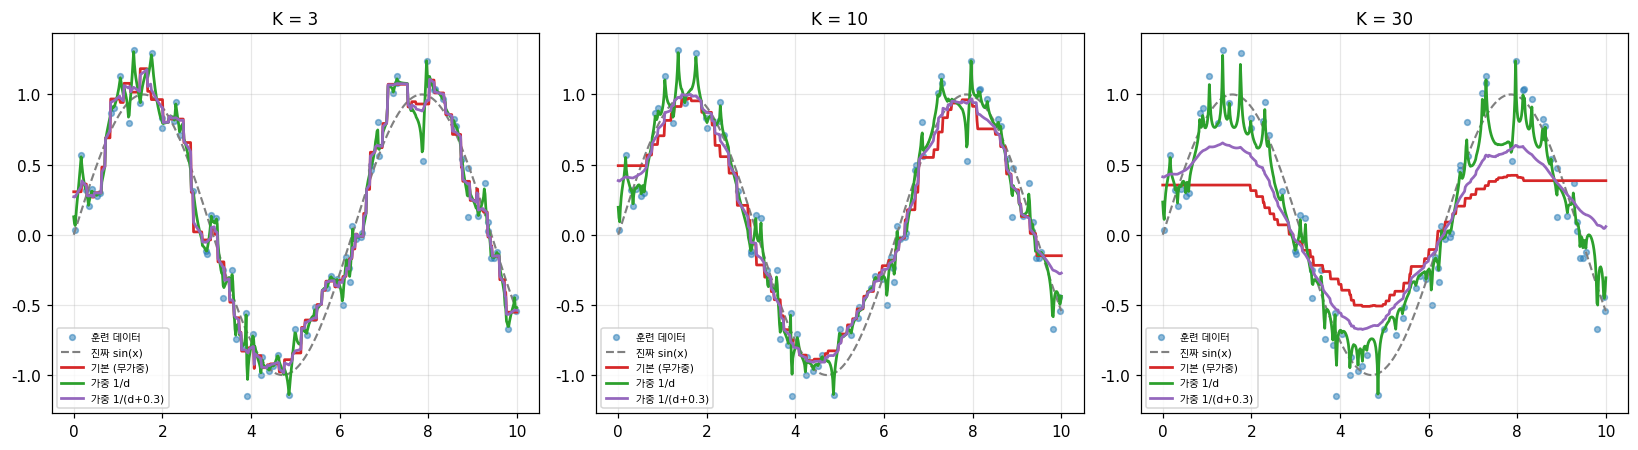

K=3  : 셋 다 잡음을 따라다닙니다. K가 작아서 과적합이에요.
K=30 : 빨간 선(기본)이 확 뭉개집니다. 이웃 30개를 그냥 평균 내니까요.
       초록·보라(가중)는 모양을 유지합니다. 먼 이웃의 표를 깎았기 때문입니다.
       보라(엡실론 0.3)가 가장 매끄럽습니다.


In [23]:
# ✨ 추가 — 위 표를 그림으로
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
색 = {"기본 (무가중)": "tab:red", "가중 1/d": "tab:green", "가중 1/(d+0.3)": "tab:purple"}
for a_, K in zip(ax, [3, 10, 30]):
    a_.scatter(X회귀, y회귀, s=14, c="tab:blue", alpha=0.5, label="훈련 데이터")
    a_.plot(격자, 진짜값, lw=1.4, c="gray", ls="--", label="진짜 sin(x)")
    for 이름, _ in 방식들:
        a_.plot(격자, 곡선모음[(K, 이름)], lw=1.8, c=색[이름], label=이름)
    a_.set_title(f"K = {K}", fontsize=11)
    a_.legend(fontsize=7); a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("K=3  : 셋 다 잡음을 따라다닙니다. K가 작아서 과적합이에요.")
print("K=30 : 빨간 선(기본)이 확 뭉개집니다. 이웃 30개를 그냥 평균 내니까요.")
print("       초록·보라(가중)는 모양을 유지합니다. 먼 이웃의 표를 깎았기 때문입니다.")
print("       보라(엡실론 0.3)가 가장 매끄럽습니다.")

In [24]:
# ✨ 추가 — '외삽 못 함'을 숫자로 못 박습니다
회귀모델 = 빠른KNN(k=5, 작업="회귀").학습(X회귀, y회귀)
바깥질문 = np.array([[-3.0], [-1.0], [11.0], [50.0], [1000.0]])
바깥예측 = 회귀모델.예측(바깥질문)

print(f"훈련 데이터의 x 범위: {X회귀.min():.2f} ~ {X회귀.max():.2f}")
print(f"훈련 데이터의 y 범위: {y회귀.min():.3f} ~ {y회귀.max():.3f}\n")
print(f"{'질문 x':>10}{'KNN 예측':>12}{'진짜 sin(x)':>14}")
print("-" * 38)
for q, p in zip(바깥질문.ravel(), 바깥예측):
    print(f"{q:>10.1f}{p:>12.4f}{math.sin(q):>14.4f}")

print(f"\n=> x=11이든 x=1000이든 예측이 똑같습니다 ({바깥예측[-1]:.4f}).")
print("   범위 밖에서는 '가장 오른쪽 점 5개'가 항상 같은 이웃이라 답이 안 변합니다.")
print(f"   그리고 예측값은 절대 [{y회귀.min():.3f}, {y회귀.max():.3f}] 밖으로 못 나갑니다. 평균이니까요.")

# 선형 회귀와 비교
from sklearn.linear_model import LinearRegression
선형 = LinearRegression().fit(X회귀, y회귀)
print(f"\n참고 — 선형 회귀는 x=1000에서 {선형.predict([[1000.0]])[0]:.1f} 을 내놓습니다.")
print("   (틀린 값이지만 '범위 밖으로 나갈 수는 있다'는 점이 다릅니다.)")

훈련 데이터의 x 범위: 0.03 ~ 9.97
훈련 데이터의 y 범위: -1.149 ~ 1.314

      질문 x      KNN 예측     진짜 sin(x)
--------------------------------------
      -3.0      0.2890       -0.1411
      -1.0      0.2890       -0.8415
      11.0     -0.3890       -1.0000
      50.0     -0.3890       -0.2624
    1000.0     -0.3890        0.8269

=> x=11이든 x=1000이든 예측이 똑같습니다 (-0.3890).
   범위 밖에서는 '가장 오른쪽 점 5개'가 항상 같은 이웃이라 답이 안 변합니다.
   그리고 예측값은 절대 [-1.149, 1.314] 밖으로 못 나갑니다. 평균이니까요.

참고 — 선형 회귀는 x=1000에서 -21.0 을 내놓습니다.
   (틀린 값이지만 '범위 밖으로 나갈 수는 있다'는 점이 다릅니다.)


---

## 1️⃣1️⃣ 실무 — sklearn과 벡터 검색

> 🔗 **앞 절과 이어서** — 여기까지가 KNN의 전부입니다. 이제 이걸 **어디에 쓰는지** 봅니다.
> 도입부에서 "KNN은 이름만 바뀌어 최신 AI 곳곳에 있다"고 했죠. 그 이야기를 마무리합니다.

> 📗 **원문** — "Use It"

```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, metric="euclidean")),
])
```

> 📗 sklearn은 데이터 크기와 차원을 보고 **KD-트리·볼 트리·무차별 탐색을 알아서 고릅니다.**
> `algorithm` 파라미터로 직접 지정할 수도 있어요.

### 📗 볼 트리는 뭔가요?

KD-트리가 **축에 나란한 상자**로 쪼갠다면, 볼 트리는 **공(중심 + 반지름)**으로 쪼갭니다.

- 중간 차원(~50)까지 KD-트리보다 낫습니다
- 축에 나란하지 않은 구조도 잘 다룹니다
- 경계가 더 꽉 맞아서 **가지를 더 많이 쳐낼 수 있습니다**

### 🏭 진짜 대규모라면

수백만 벡터 × 수백 차원이면 **정확한 탐색을 포기합니다.**
FAISS, Annoy, 또는 벡터 DB를 씁니다.

```python
import faiss
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
distances, indices = index.search(query_vectors, k=5)
```

> **이 단원에서 배운 게 곧 RAG 파이프라인의 검색 단계입니다.**
> 질문을 임베딩하고 → 가장 가까운 문서 조각 K개를 찾고 → LLM에 붙여 넣습니다.
> 알고리즘은 여러분이 2절에서 만든 그것과 똑같습니다.

In [25]:
# 📗 원문 Use It — 파이프라인 + 알고리즘 자동 선택 확인
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = Pipeline([("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(n_neighbors=5, metric="euclidean"))]).fit(X, y)
print(f"파이프라인 테스트 정확도: {clf.score(Xte, yte):.4f}\n")

print("sklearn이 실제로 고른 알고리즘")
print(f"{'차원':>6}{'algorithm=auto 가 고른 것':>26}")
print("-" * 34)
for d in [2, 10, 30, 100]:
    Xd, yd = 차원늘린데이터(0, 1000, d - 2)
    m = KNeighborsClassifier(n_neighbors=5, algorithm="auto").fit(Xd, yd)
    print(f"{d:>6}{m._fit_method:>26}")
print("\n=> 저차원에서는 트리를, 고차원에서는 무차별 탐색을 고릅니다.")
print("   방향은 8절에서 우리가 측정한 것과 같습니다. 다만 갈아타는 지점은 다릅니다.")
print("   sklearn의 트리는 C로 짜여 있어서 더 오래 버팁니다.")
print("   우리 트리는 파이썬 재귀라 오버헤드가 커서 훨씬 일찍 손해로 돌아섰죠.")
print("   💡 '알고리즘의 복잡도'와 '실제 속도'는 다르다는 좋은 예입니다.")

파이프라인 테스트 정확도: 0.9400

sklearn이 실제로 고른 알고리즘
    차원     algorithm=auto 가 고른 것
----------------------------------
     2                   kd_tree
    10                   kd_tree
    30                     brute
   100                     brute

=> 저차원에서는 트리를, 고차원에서는 무차별 탐색을 고릅니다.
   방향은 8절에서 우리가 측정한 것과 같습니다. 다만 갈아타는 지점은 다릅니다.
   sklearn의 트리는 C로 짜여 있어서 더 오래 버팁니다.
   우리 트리는 파이썬 재귀라 오버헤드가 커서 훨씬 일찍 손해로 돌아섰죠.
   💡 '알고리즘의 복잡도'와 '실제 속도'는 다르다는 좋은 예입니다.


In [26]:
# ✨ 추가 — 미니 RAG: KNN이 검색 단계에서 하는 일 그대로
문서들 = [
    "고양이는 하루 16시간을 잡니다",
    "강아지는 산책을 아주 좋아합니다",
    "파이썬은 배우기 쉬운 프로그래밍 언어입니다",
    "자바스크립트는 웹 브라우저에서 돌아갑니다",
    "고양이는 그루밍에 많은 시간을 씁니다",
    "경사하강법은 손실을 줄이는 방향으로 갑니다",
]

# 진짜 임베딩 모델 대신, 글자 단위 특징으로 흉내만 냅니다
def 대충임베딩(문장, 차원=64):
    v = np.zeros(차원)
    for i in range(len(문장) - 1):
        v[hash(문장[i:i+2]) % 차원] += 1.0
    return v

문서벡터 = np.array([대충임베딩(d) for d in 문서들])
질문 = "고양이는 잠을 얼마나 자나요"
질문벡터 = 대충임베딩(질문)

거리 = np.array([코사인거리(질문벡터, v) for v in 문서벡터])
상위 = np.argsort(거리)[:3]

print(f"질문: {질문}\n")
print("가장 가까운 문서 3개 (코사인 거리 기준)")
print("-" * 52)
for 등수, i in enumerate(상위, 1):
    print(f"  {등수}위 (거리 {거리[i]:.4f})  {문서들[i]}")

print("\n=> 이게 RAG의 검색 단계 전부입니다. K=3인 KNN이에요.")
print("   실무에서는 대충임베딩 대신 진짜 임베딩 모델을,")
print("   무차별 탐색 대신 FAISS 같은 근사 탐색을 씁니다. 원리는 똑같습니다.")

질문: 고양이는 잠을 얼마나 자나요

가장 가까운 문서 3개 (코사인 거리 기준)
----------------------------------------------------
  1위 (거리 0.6311)  고양이는 하루 16시간을 잡니다
  2위 (거리 0.6437)  경사하강법은 손실을 줄이는 방향으로 갑니다
  3위 (거리 0.6482)  강아지는 산책을 아주 좋아합니다

=> 이게 RAG의 검색 단계 전부입니다. K=3인 KNN이에요.
   실무에서는 대충임베딩 대신 진짜 임베딩 모델을,
   무차별 탐색 대신 FAISS 같은 근사 탐색을 씁니다. 원리는 똑같습니다.


---

## 1️⃣2️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 진짜 무슨 뜻인가 |
| --- | --- |
| **K-최근접 이웃** | 질문점에서 가장 가까운 훈련점 K개로 답하는 방법. 파라미터가 없습니다 |
| **게으른 학습** | 훈련 때 계산 0. 전부 예측할 때 합니다. KNN이 대표 사례 |
| **부지런한 학습** | 훈련 때 열심히 계산해서 작은 모델을 만듭니다. 대부분의 ML이 여기 속함 |
| **차원의 저주** | 차원이 높으면 거리가 다 비슷해지고 이웃이 공간 전체가 되어 KNN이 무의미해짐 |
| **KD-트리** | 축 방향으로 공간을 반씩 쪼갠 이진 트리. 저차원에서 $O(\log n)$ |
| **볼 트리** | 공(중심+반지름)으로 쪼갠 트리. 중간 차원(~50)까지 KD-트리보다 나음 |
| **가중 KNN** | 거리에 반비례해 표의 무게를 줍니다. 가까운 이웃이 더 큰 목소리를 냄 |
| **특징 스케일링** | 특징들을 비슷한 범위로 맞추기. **거리 기반 방법에는 필수** |
| **다수결** | 이웃 K개 중 가장 많이 나온 클래스를 답으로 |
| **무차별 탐색** | 모든 점과 거리를 재는 것. $O(n \cdot d)$. 정확하지만 느림 |
| **근사 최근접 이웃** | HNSW·LSH·IVF 등. 정확함을 조금 포기하고 훨씬 빠르게 찾음 |
| **보로노이 다이어그램** | 각 훈련점이 지배하는 영역으로 공간을 쪼갠 그림. **K=1 KNN의 경계가 정확히 이것** |

---

## ✅ 이 단원 요약 (5줄)

1. KNN은 **저장만 하고, 예측할 때 이웃 K명에게 물어봅니다.** 학습 단계가 없습니다.
2. **K**가 유일한 손잡이입니다. 작으면 과적합, 크면 과소적합.
3. **거리 함수**가 "가깝다"를 정의합니다. 텍스트·임베딩이면 코사인을 쓰세요.
4. **차원이 높으면 무너집니다.** 거리가 다 비슷해져서 "가장 가깝다"가 의미를 잃습니다.
5. KNN은 **회귀에서 외삽을 못 합니다.** 답이 항상 훈련 답들 사이에 갇힙니다.

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (대부분 본문에서 이미 풀었습니다)

1. 3클래스 2차원 데이터에서 K=1, 5, 15, N의 결정 경계를 그려 보세요. → *3절에서 함*
2. 2~500차원에서 최대/최소 거리 비율을 재어 그래프로 그려 보세요. → *7절에서 함*
3. TF-IDF 텍스트에서 L1·L2·코사인을 비교해 보세요. 왜 코사인이 이길까요? → *4절에서 함*
4. KD-트리와 무차별 탐색의 질의 시간을 재고, 몇 차원부터 트리가 손해인지 찾으세요. → *8절에서 함*
5. `y = sin(x) + 잡음`에 가중/비가중 KNN 회귀를 비교해 보세요. → *10절에서 함*

### ✨ 추가 도전 과제

6. 2절의 `빠른KNN`은 L2 거리만 씁니다. **코사인·L1도 벡터화**해서 넣고, 4절의 문서 실험을 다시 돌려 보세요. 얼마나 빨라지나요?
7. 8절의 `KD트리`에 **볼 트리**를 추가로 만들어, 차원 10~50에서 어느 쪽이 더 많이 가지치기하는지 비교해 보세요.
8. 7절의 차원의 저주 실험에서, 잡음 차원을 붙이기 **전에 PCA로 2차원으로 줄이면** 정확도가 회복되는지 확인해 보세요.
9. 11절의 미니 RAG에서 `대충임베딩` 대신 `sklearn.feature_extraction.text.TfidfVectorizer`를 써서 검색 품질이 어떻게 달라지는지 보세요.

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Cover & Hart: Nearest Neighbor Pattern Classification (1967)](https://ieeexplore.ieee.org/document/1053964) — KNN의 오차가 최적 베이즈 오차의 2배를 넘지 않음을 증명한 논문
- [Friedman, Bentley, Finkel (1977)](https://dl.acm.org/doi/10.1145/355744.355745) — KD-트리 원 논문
- [Beyer et al.: When Is "Nearest Neighbor" Meaningful? (1999)](https://link.springer.com/chapter/10.1007/3-540-49257-7_15) — 차원의 저주를 정식으로 분석한 논문
- [scikit-learn Nearest Neighbors 문서](https://scikit-learn.org/stable/modules/neighbors.html)
- [FAISS](https://github.com/facebookresearch/faiss) — 메타의 대규모 근사 최근접 이웃 라이브러리